0_KmeansSegmentationk_16max_iter_200color_scheme_gist_rainbow0
original


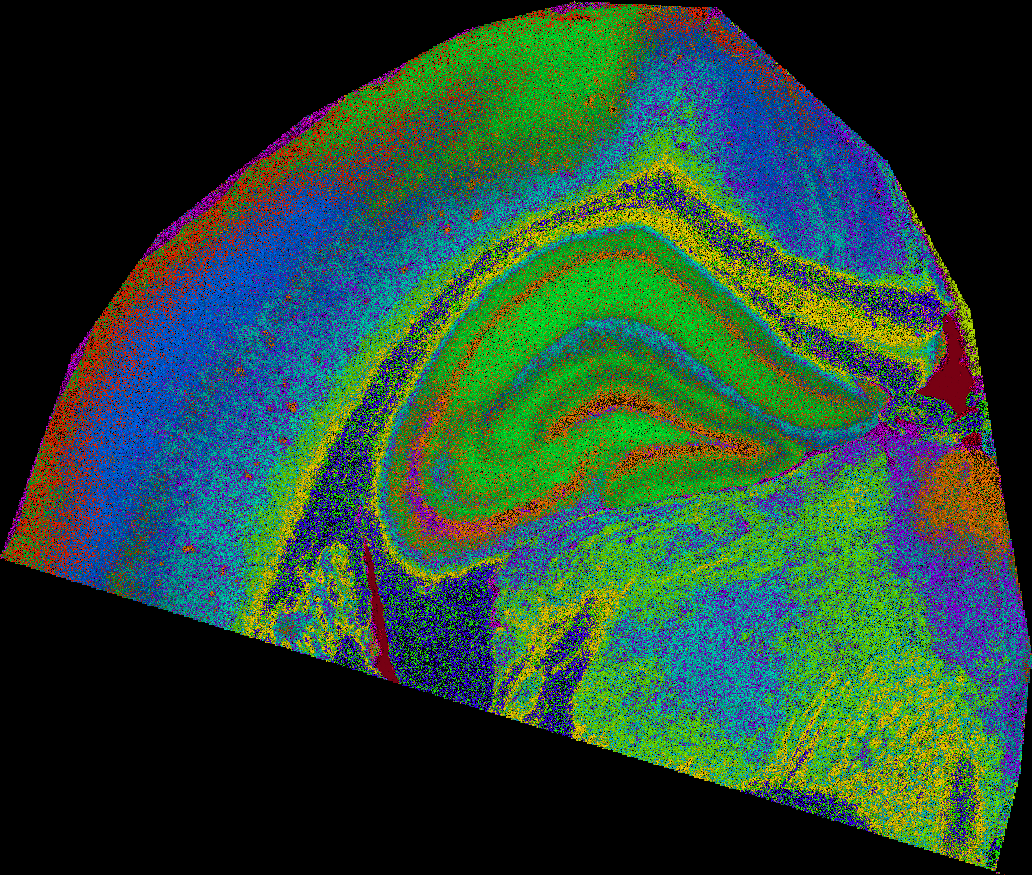

0_KmeansSegmentationk_16max_iter_200color_scheme_gist_rainbow0
original equalized


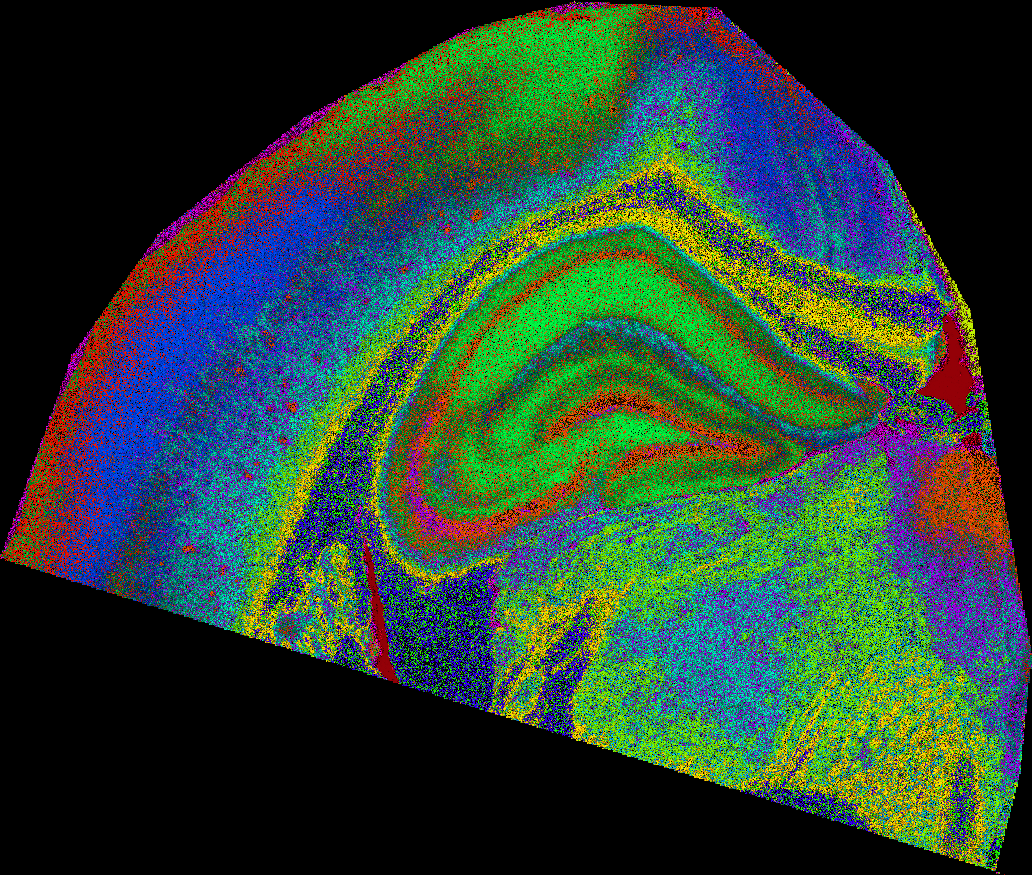

RGB channels ordered and equalized


KeyboardInterrupt: 

In [ ]:
import glob, cv2
from pathlib import Path
from PIL import Image
import numpy as np
import os

#paths
#NRL4509 atlas slides lipids 300-1350Da
#paths = glob.glob(r"E:\MSImaging-data\_msi_visual\Visualizations\visualizations_NRL4509-atlas_5bins\s1+s6\*.png")
#paths = glob.glob(r"E:\MSImaging-data\_msi_visual\Visualizations\visualizations_NRL4509-atlas_5bins\s8\*.png")


#human slides lipids 300-2100Da
#paths = glob.glob(r"E:\MSImaging-data\_msi_visual\Visualizations\visualizations_PXD049325-lip_5bins\*.png")

#human slides peptides 2-17kDa
#paths = glob.glob(r"E:\MSImaging-data\_msi_visual\Visualizations\visualizations_PXD049325-pep_5bins\3rd-run\*.png")
#paths = glob.glob(r"E:\MSImaging-data\_msi_visual\Visualizations\visualizations_PXD049325-pep_5bins\2nd-run\*.png")
#paths = glob.glob(r"E:\MSImaging-data\_msi_visual\Visualizations\visualizations_PXD049325-pep_5bins\1st-run\*.png")

#benchmark
#paths = glob.glob(r"C:\Users\PahnkeLab\Desktop\Maldi_MSI\msi_visual\benchmark_after_fix\*.png")

#5µm whole hemisphere lipids 300-1350Da
#paths = glob.glob(r"E:\MSImaging-data\_msi_visual\Visualizations\visualizations_NRL4506-5um\10_bins\*.png")
#paths = glob.glob(r"E:\MSImaging-data\_msi_visual\Visualizations\visualizations_NRL4506-5um\5_bins\*.png")

#5µm small stripes lipids 300-1350Da
#paths = glob.glob(r"E:\MSImaging-data\_msi_visual\Visualizations\visualizations_NRL4485-s6-5um-5bins\*.png")

#5µm saliency testing 
#paths = glob.glob(r"E:\MSImaging-data\_msi_visual\Visualizations\visualizations_NRL4485-s6-5um-5bins\saliency\*.png")

#neoflex NRL4511 NEDC+DHB neg + pos lipids 
#paths = glob.glob(r"E:\MSImaging-data\_msi_visual\Visualizations\visualizations_NRL4511-neoflex-5bins\neg\*.png")
#paths = glob.glob(r"E:\MSImaging-data\_msi_visual\Visualizations\visualizations_NRL4511-neoflex-5bins\pos\*.png")

#NRL4485-s2 - new extraction 5 and 10 bins
#paths = glob.glob(r"E:\MSImaging-data\_msi_visual\Visualizations\visualizations_NRL4485-s2\5_bins\*.png")
#paths = glob.glob(r"E:\MSImaging-data\_msi_visual\Visualizations\visualizations_NRL4485-s2\10_bins\*.png")
#paths = glob.glob(r"E:\MSImaging-data\_msi_visual\Visualizations\visualizations_NRL4485-s2\10_bins\saliency_test\*.png")
#paths = glob.glob(r"E:\MSImaging-data\_msi_visual\Visualizations\visualizations_NRL4485-s2\20_bins\*.png")

#paths = glob.glob(r"E:\MSImaging-data\_msi_visual\Visualizations\visualizations_2025_RamonSun\coronar_lip\*.png")
paths = glob.glob(r"E:\MSImaging-data\_msi_visual\Visualizations\visualizations_NRL4509-atlas-5um\s16\*.png")

for path in paths:
    img = np.array(Image.open(path))

    # Get the directory containing the original image
    orig_dir = Path(path).parent
    eq_dir = orig_dir / "equalized"
    os.makedirs(eq_dir, exist_ok=True)

    # original
    print(Path(path).stem)
    print("original")    
    display(Image.fromarray(img))

    # original equalized
    eq = cv2.merge([cv2.equalizeHist(img[:, :, i]) for i in range(3)])
    images = [eq[:, :, [0, 1, 2]]]
    eq_img = np.hstack(images)
    print(Path(path).stem)
    print("original equalized") 
    display(Image.fromarray(eq_img))

    # Save the equalized image in the "equalized" subfolder, with same filename
    eq_path = eq_dir / Path(path).name
    Image.fromarray(eq_img).save(eq_path)
    print(f"Saved equalized image to {eq_path}")

    # rgb channels ordered and equalized
    orders = [[0, 1, 2], [1, 2, 0], [2, 0, 1], [1, 0, 2], [2, 1, 0],[0, 2, 1]]
    eq = cv2.merge([cv2.equalizeHist(eq_img[:, :, i]) for i in range(3)])
    #eq = cv2.resize(eq, (eq.shape[1]//2, eq.shape[0]//2))
    images = [eq[:, :, order] for order in orders]
    rgb_orders_img = np.hstack(images)
    print("RGB channels ordered and equalized") 
    display(Image.fromarray(rgb_orders_img))
